# Khởi tạo mạng CRNN và Huấn luyện thử nghiệm
Notebook này đã được sửa đổi để khớp với kiến trúc dự án và pipeline dữ liệu của chúng ta.

In [1]:
import sys
import os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

## 1. Khởi tạo Data Loaders và Charset
Sử dụng `get_dataloaders` từ `src.dataset.loader` để tận dụng lại code đã viết.

In [22]:
from src.dataset import get_dataloaders
from src.dataset.charset import CharsetCodec

train_loader, val_loader = get_dataloaders(
    train_dirs=["data/synthetic/train"],
    val_dirs=["data/synthetic/val"],
    charset_path="data/charset.txt",
    batch_size=32,
    num_workers=0
)

codec = CharsetCodec("data/charset.txt")
print(f"Charset size: {len(codec)}")

Dataset: 20000 samples, train=True
Dataset: 2000 samples, train=False
Charset size: 248


In [23]:
# Cắt lấy 32 mẫu (đúng bằng 1 Batch)
train_loader.dataset.samples = train_loader.dataset.samples[:3200]
val_loader.dataset.samples = val_loader.dataset.samples[:320]


## 2. Trực quan hoá dữ liệu (Visualization)

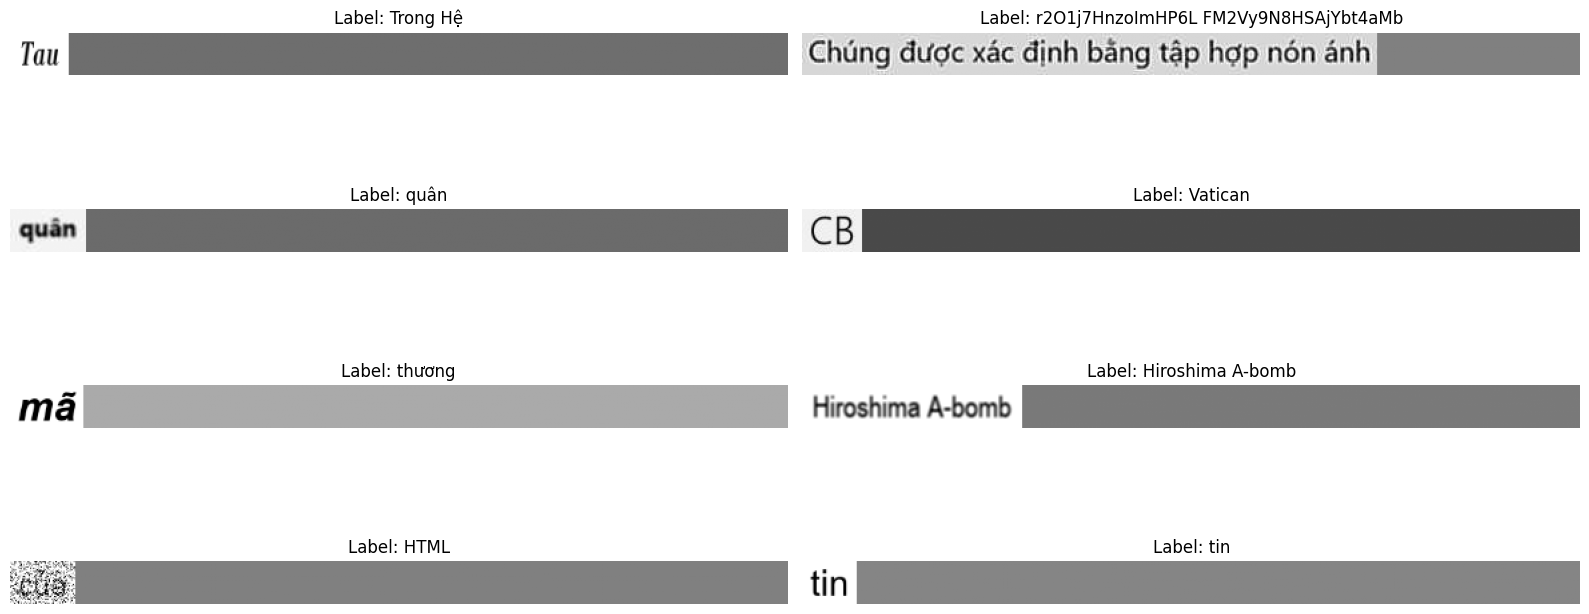

In [24]:
batch = next(iter(train_loader))
images = batch['image']
labels = batch['label']

# Giải mã label
decoded_labels = []
for label in labels:
    chars = []
    for char_id in label:
        if char_id == 0:
            continue
        chars.append(codec.idx2char[char_id.item()])
    decoded_labels.append(''.join(chars))

fig, axes = plt.subplots(4, 2, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, len(images))):
    img = images[i].cpu().numpy()
    img = np.transpose(img, (1, 2, 0)) # CHW to HWC
    # Un-normalize ảnh (nếu model ta normalize -0.5..0.5)
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {decoded_labels[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Khởi tạo Mô hình CRNN

In [16]:
from src.recognizer.model import CRNN, ctc_greedy_decode

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on device: {device}")

model = CRNN(num_classes=len(codec)).to(device)

Training on device: cuda


## 4. Vòng lặp huấn luyện (Fit & Evaluate)

In [25]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            labels = batch["label"]
            label_len = batch["label_len"]
            
            outputs = model(images)
            log_probs = outputs.log_softmax(2).permute(1, 0, 2)
            input_lengths = torch.full((images.size(0),), outputs.size(1), dtype=torch.long)
            
            loss = criterion(log_probs, labels.cpu(), input_lengths, label_len.cpu())
            losses.append(loss.item())
            
    return sum(losses) / len(losses)

def fit(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        start = time.time()
        batch_train_losses = []
        model.train()
        
        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["label"]
            label_len = batch["label_len"]

            optimizer.zero_grad()
            outputs = model(images)
            log_probs = outputs.log_softmax(2).permute(1, 0, 2)
            input_lengths = torch.full((images.size(0),), outputs.size(1), dtype=torch.long)

            loss = criterion(log_probs, labels.cpu(), input_lengths, label_len.cpu())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        print(f"EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\tTime: {time.time() - start:.2f}s")
        scheduler.step()

    return train_losses, val_losses

## 5. Bắt đầu Train

In [29]:
epochs = 10
lr = 1e-3
weight_decay = 1e-5

criterion = nn.CTCLoss(blank=0, zero_infinity=True, reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses, val_losses = fit(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs
)

EPOCH 1:	Train loss: 4.8050	Val loss: 4.5227	Time: 23.32s
EPOCH 2:	Train loss: 4.7169	Val loss: 4.4249	Time: 22.82s
EPOCH 3:	Train loss: 4.6758	Val loss: 4.3936	Time: 22.91s
EPOCH 4:	Train loss: 4.6321	Val loss: 4.2838	Time: 23.38s
EPOCH 5:	Train loss: 4.6042	Val loss: 4.2807	Time: 23.14s
EPOCH 6:	Train loss: 4.5531	Val loss: 4.2181	Time: 23.38s
EPOCH 7:	Train loss: 4.5299	Val loss: 4.1936	Time: 23.09s
EPOCH 8:	Train loss: 4.5133	Val loss: 4.1795	Time: 23.49s
EPOCH 9:	Train loss: 4.5100	Val loss: 4.1413	Time: 23.64s
EPOCH 10:	Train loss: 4.4885	Val loss: 4.0662	Time: 23.70s


## 6. Plot Biểu đồ Loss

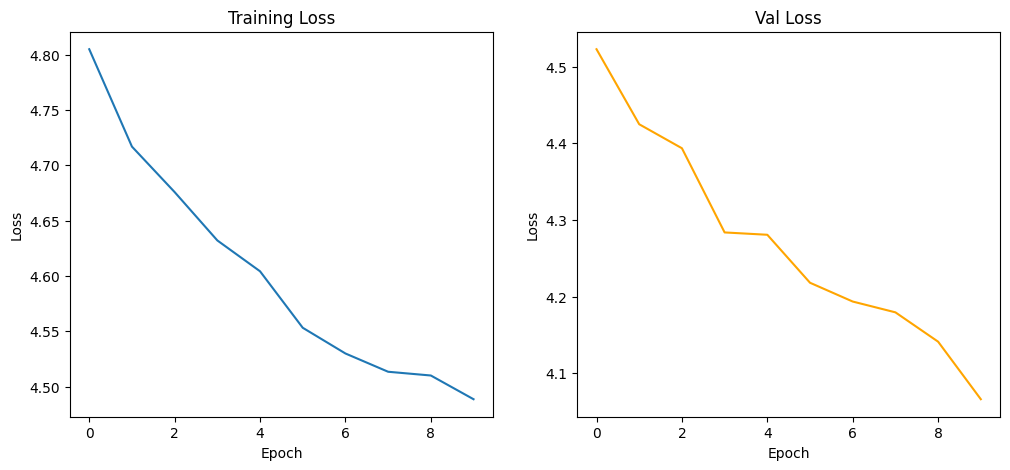

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(val_losses, color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()

## 7. Đánh giá trực quan mô hình sau khi Train

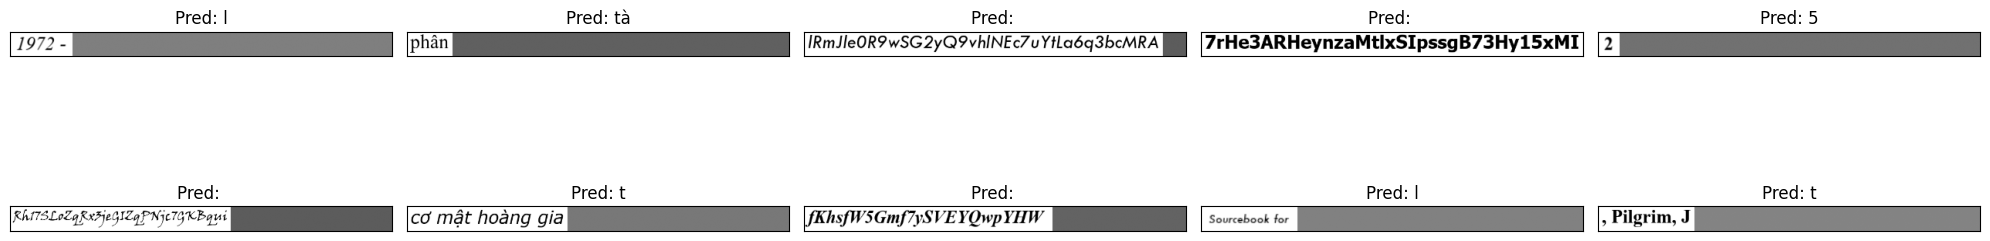

In [31]:
model.eval()
batch = next(iter(val_loader))
images = batch['image'].to(device)

with torch.no_grad():
    outputs = model(images)
    preds = ctc_greedy_decode(outputs, codec.charset)

fig = plt.figure(figsize=(20, 5))
for i in range(min(10, len(images))):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    
    img = images[i].cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    
    pred_text = preds[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {pred_text}")

plt.tight_layout()
plt.show()